In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


slp = pd.read_sas('.data/raw/P_SLQ.xpt')
demo = pd.read_sas('.data/raw/P_DEMO.xpt')
bmx  = pd.read_sas('.data/raw/P_BMX.xpt')
alq  = pd.read_sas('.data/raw/P_ALQ.xpt')
paq  = pd.read_sas('.data/raw/P_PAQ.xpt')
bpc = pd.read_sas('.data/raw/P_BPQ.xpt')
inc = pd.read_sas('.data/raw/P_INQ.xpt')
dbq= pd.read_sas('.data/raw/P_DBQ.xpt')
dr= pd.read_sas('.data/raw/P_DR1TOT.xpt')

print(alq)

          SEQN  ALQ111        ALQ121  ALQ130        ALQ142        ALQ270  \
0     109266.0     1.0  1.000000e+01     1.0  5.397605e-79           NaN   
1     109271.0     1.0  5.397605e-79     NaN           NaN           NaN   
2     109273.0     1.0  5.397605e-79     NaN           NaN           NaN   
3     109274.0     1.0  4.000000e+00     2.0  5.000000e+00  7.000000e+00   
4     109282.0     1.0  5.397605e-79     NaN           NaN           NaN   
...        ...     ...           ...     ...           ...           ...   
8960  124815.0     1.0  3.000000e+00     1.0  5.397605e-79           NaN   
8961  124817.0     1.0  3.000000e+00     2.0  5.397605e-79           NaN   
8962  124818.0     1.0  9.000000e+00     2.0  5.397605e-79           NaN   
8963  124821.0     1.0  5.000000e+00     5.0  7.000000e+00  5.397605e-79   
8964  124822.0     1.0  6.000000e+00     2.0  5.397605e-79           NaN   

            ALQ280  ALQ290  ALQ151        ALQ170  
0              NaN     NaN     2.0  

**Merge the datasets**

In [37]:
df = demo.merge(bmx, on="SEQN", how="inner") \
         .merge(alq, on="SEQN", how="inner") \
         .merge(paq, on="SEQN", how="inner") \
            .merge(slp, on="SEQN", how="inner")\
            .merge(bpc, on="SEQN", how="inner")\
            .merge(inc, on="SEQN", how="inner")\
            .merge(dbq,on="SEQN", how="inner")\
            .merge(dr,on="SEQN", how="inner")

**Feature Selection**

In [38]:
df = df[
[
"SEQN",
"RIDAGEYR",
"RIAGENDR",
"BMXBMI",
"ALQ111",
"ALQ130",
"PAQ605",
"PAQ620",
"SLD012",
"INDFMMPI",
"BPQ020",
"DR1TKCAL",
"DR1TSUGR",
"DR1TTFAT",
"DR1TPROT",
"DR1TSODI",
"DBD895",
"DBD900"
]
]

In [39]:
df = df.replace(5.397605e-79, np.nan)

**Null Values**

In [40]:
df.isnull().sum()

SEQN           0
RIDAGEYR       0
RIAGENDR       0
BMXBMI       175
ALQ111       595
ALQ130      3102
PAQ605         0
PAQ620         0
SLD012        79
INDFMMPI    1904
BPQ020         0
DR1TKCAL     873
DR1TSUGR     873
DR1TTFAT     873
DR1TPROT     873
DR1TSODI     873
DBD895         0
DBD900      1896
dtype: int64

**Handling missing values**

In [41]:
#handling missing values.
for col in ['DR1TKCAL','DR1TSUGR','DR1TTFAT','DR1TPROT','DR1TSODI']:
    df[col + '_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())
df['DBD900_missing'] = df['DBD900'].isna().astype(int)
df['DBD900'] = df['DBD900'].fillna(0)
df["ALQ111"] = df["ALQ111"].fillna(3) # Assuming unknown drinking as 3 which is other category. 
df["SLD012"] = df["SLD012"].fillna(df["SLD012"].median())
df["INDFMMPI"] = df["INDFMMPI"].fillna(df["INDFMMPI"].mean()) # Assuming mean for continuous variable.

In [42]:
df["RIAGENDR"] = df["RIAGENDR"].map({1: 0, 2: 1})
df["ALQ111"] = (df["ALQ111"] == 1).astype(int)
#df["BPQ020"] = (df["BPQ020"] == 1).astype(int)

In [43]:
#drop rows with bmi missing values, because we cannot calculate the target variable without it
df = df.dropna(subset=["BMXBMI"])

**Transforming the Target values**

In [44]:
df["Obese"] = df["BMXBMI"].apply(lambda x: 1 if x >= 30 else 0)

**Feature Engineering**

In [45]:
df['protein_ratio'] = df['DR1TPROT'] / df['DR1TKCAL']
df['sugar_ratio'] = df['DR1TSUGR'] / df['DR1TKCAL']
df['sodium_density'] = df['DR1TSODI'] / df['DR1TKCAL']
df['fast_food_ratio'] = df['DBD900'] / (df['DBD895'] + 1)
df['calorie_activity'] = df['DR1TKCAL'] * df['PAQ605']
df['fat_calorie_ratio'] = df['DR1TTFAT'] / df['DR1TKCAL']
df['diet_quality'] = df['protein_ratio'] - df['sugar_ratio']

In [46]:
df['log_calories'] = np.log1p(df['DR1TKCAL'])
df['log_sodium'] = np.log1p(df['DR1TSODI'])

**Droped low signal or irrelevant columns**

In [47]:
X = df.drop(columns=["SEQN", "Obese", "PAQ605", "DR1TSODI","SEQN","ALQ111","DR1TKCAL_missing",
    "DR1TSUGR_missing",
    "DR1TTFAT_missing",
    "DR1TPROT_missing",
    "DR1TSODI_missing","diet_quality",      # derived from ratios → remove
    "DR1TPROT",          # raw → redundant
    "DR1TSUGR",          # raw → redundant
    "DR1TTFAT","DR1TKCAL","ALQ130","BMXBMI"]) # raw → redundant
y = df["Obese"]

**Data split**

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Transform the train set and test set features separately**

In [49]:
from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

**Train the model**

**XGBoost**

In [50]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.5,   # we'll fix this next
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

**Random Forest**


In [51]:
# from sklearn.ensemble import RandomForestClassifier
# model = RandomForestClassifier(
#     n_estimators=300,
#     max_depth=9,
#     min_samples_split=7,
#     min_samples_leaf=2,
#     class_weight='balanced',   # important
#     random_state=42,
#     n_jobs=-1
# )
# # Train
# model.fit(X_train, y_train)

**Logistic Regression**

In [52]:
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(
#     C=0.04296861889693622,
#     l1_ratio=0.4448266550525032,
#     class_weight='balanced',
#     penalty='elasticnet',
#     solver='saga',
#     max_iter=1000,
#     random_state=42
# )
# model.fit(X_train, y_train)

**Best Threshold**

In [53]:
# from sklearn.metrics import f1_score
# best_t = None
# best_f1 = 0
# y_pred = model.predict(X_test)
# y_pred_proba = model.predict_proba(X_test)[:, 1]
# thresholds = np.arange(0.3, 0.5, 0.05)
# for t in thresholds:
#     y_pred_t = (y_pred_proba >= t).astype(int)
#     f1 = f1_score(y_test, y_pred_t)
    
#     if f1 > best_f1:
#         best_f1 = f1
#         best_t = t

# print("Best threshold:", best_t)

**Prediction**

In [54]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

**Evaluation**

In [55]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

threshold = 0.35
y_pred = (y_pred_proba >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5409556313993175

               precision    recall  f1-score   support

           0       0.72      0.32      0.45      1008
           1       0.48      0.83      0.61       750

    accuracy                           0.54      1758
   macro avg       0.60      0.58      0.53      1758
weighted avg       0.62      0.54      0.52      1758


Confusion Matrix:
 [[327 681]
 [126 624]]


**Feature Importance**

In [56]:
# import pandas as pd

# importance = pd.Series(rf.coef_[0], index=X.columns)
# print(importance.sort_values(ascending=False))
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

BPQ020               0.216536
fast_food_ratio      0.068261
RIAGENDR             0.065640
RIDAGEYR             0.060475
INDFMMPI             0.052041
fat_calorie_ratio    0.051034
sodium_density       0.048459
PAQ620               0.046923
sugar_ratio          0.044585
log_sodium           0.044349
log_calories         0.043930
DBD900_missing       0.043523
DBD900               0.043404
protein_ratio        0.043382
DBD895               0.043080
calorie_activity     0.042472
SLD012               0.041905
dtype: float32


**ROC-AUC score**

In [57]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.6462619047619047


**ROC Curve**

ROC-AUC Score: 0.6462619047619047


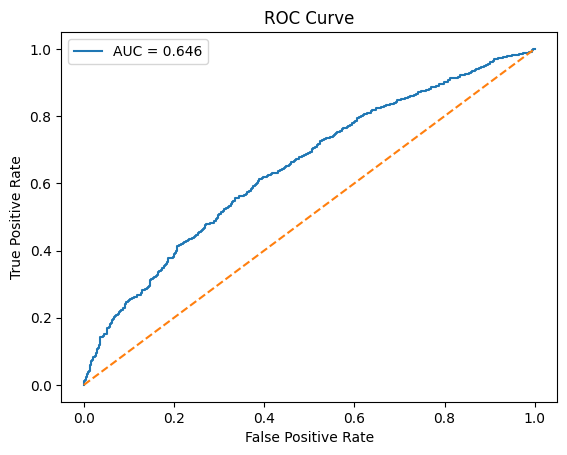

In [58]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# AUC Score
print("ROC-AUC Score:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Model Artifacts**

In [59]:
#scalar and model artifacts
import pickle
from pathlib import Path

artifact_model = Path("./artifacts/model")
artifact_model.mkdir(parents=True, exist_ok=True)

# Save model
with open(artifact_model / "model.pkl", "wb") as f:
    pickle.dump(model, f)

# # Save scaler (if you used one)
# with open(artifact_model / "scaler.pkl", "wb") as f:
#     pickle.dump(scaler, f)

print("✓ Model and scaler saved")

✓ Model and scaler saved


**Feature Artifacts**

In [60]:
#features
import pandas as pd

artifact_feature= Path("./artifacts/feature")
artifact_feature.mkdir(parents=True, exist_ok=True)
feature_info = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

feature_info = feature_info.sort_values(by="importance", ascending=False)

feature_info.to_csv(artifact_feature / "feature_importance.csv", index=False)

print("✓ Feature importance saved")

✓ Feature importance saved


In [61]:
from datetime import datetime
import json
from pathlib import Path
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, accuracy_score

# Ensure probabilities are correct
y_pred_proba = model.predict_proba(X_test)[:, 1]

metadata = {
    "model_version": "v1.0",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    
    "model_type": "XGBoostClassifier",
    "threshold": 0.35,
    
    "metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1_score": float(f1_score(y_test, y_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_pred_proba))
    },
    
    "model_params": model.get_params(),
    "features": list(X.columns),
    "num_features": X.shape[1],
    "notes": "XGBoost with threshold tuning and feature engineering"
}

metadata_dir = Path("./artifacts/metadata")
metadata_dir.mkdir(parents=True, exist_ok=True)

with open(metadata_dir / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("✓ Model metadata saved")

✓ Model metadata saved


In [62]:
import pandas as pd
from pathlib import Path

data_dir = Path("./artifacts/data")
data_dir.mkdir(parents=True, exist_ok=True)

# Ensure DataFrame consistency
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Save features
X_train_df.to_csv(data_dir / "X_train.csv", index=False)
X_test_df.to_csv(data_dir / "X_test.csv", index=False)

# Save target with name
pd.Series(y_train, name="target").to_csv(data_dir / "y_train.csv", index=False)
pd.Series(y_test, name="target").to_csv(data_dir / "y_test.csv", index=False)

print("✓ Data artifacts saved")

✓ Data artifacts saved


In [63]:
import pandas as pd
from pathlib import Path

def generate_data_quality_report(X, save_path="./artifacts/reports/data_quality_report.csv"):
    
    report_dir = Path(save_path).parent
    report_dir.mkdir(parents=True, exist_ok=True)

    # Basic stats
    missing = X.isnull().sum()
    missing_pct = (missing / len(X)) * 100
    unique = X.nunique()
    dtypes = X.dtypes

    # Numeric stats (aligned safely)
    numeric_stats = X.describe().T  # transpose for feature-wise view

    # Build report
    quality_report = pd.DataFrame({
        "feature": X.columns,
        "dtype": dtypes.values,
        "missing_values": missing.values,
        "missing_%": missing_pct.values,
        "unique_values": unique.values,
        "is_constant": (unique.values <= 1),
        "high_missing_flag": (missing_pct.values > 30)
    })

    # Merge numeric stats safely
    numeric_stats = numeric_stats[["mean", "std", "min", "max"]] if "mean" in numeric_stats.columns else pd.DataFrame()
    
    quality_report = quality_report.merge(
        numeric_stats,
        left_on="feature",
        right_index=True,
        how="left"
    )

    # Save
    quality_report.to_csv(save_path, index=False)

    print("✓ Data quality report saved")
    return quality_report


# 👉 Call it
quality_report = generate_data_quality_report(X)

✓ Data quality report saved
